In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA

def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

## Loading and Examining Pictures Data

In [30]:
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# introspect the images arrays to find the shapes (for plotting)
n_samples, h, w = lfw_people.images.shape

# for machine learning we use the 2 data directly (as relative pixel
# positions info is ignored by this model)
X = lfw_people.data
n_features = X.shape[1]

# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print("Total dataset size:")
print(f"Original dimensions of each picture: {lfw_people.images[0].shape}")
print(f"n_samples: {n_samples}")
print(f"n_features (stacked images): {n_features}")
print(f"n_classes: {n_classes}\n")
_, counts = np.unique(y, return_counts=True)
for name, count in zip(target_names, counts):
    print(f"{name}: {count}")

Total dataset size:
Original dimensions of each picture: (50, 37)
n_samples: 1288
n_features (stacked images): 1850
n_classes: 7

Ariel Sharon: 77
Colin Powell: 236
Donald Rumsfeld: 121
George W Bush: 530
Gerhard Schroeder: 109
Hugo Chavez: 71
Tony Blair: 144


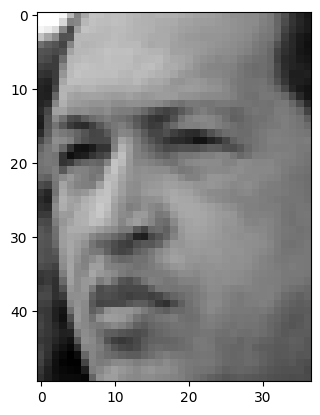

In [ ]:
# Plotting one face using imshow
plt.imshow(X[0].reshape((h, w)), cmap=plt.cm.gray)
plt.show()

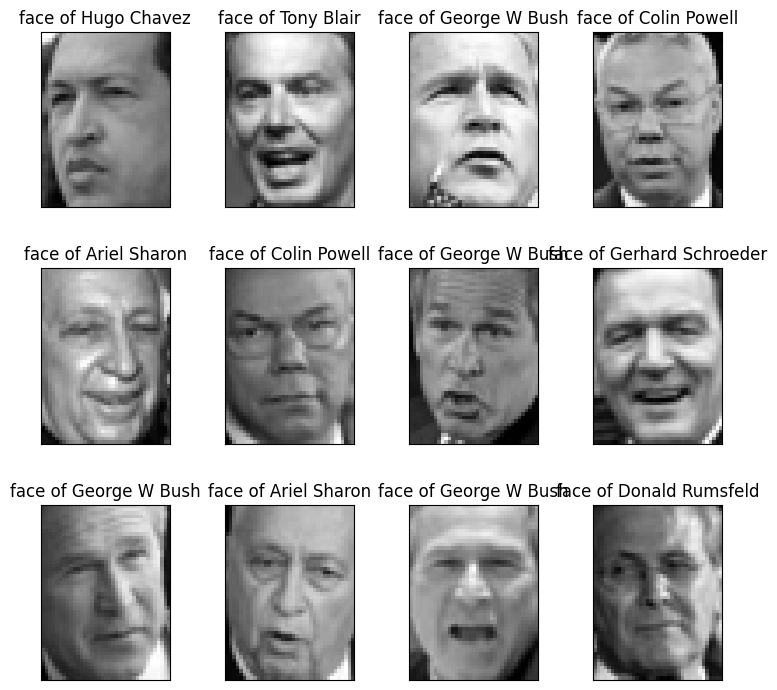

In [ ]:
# Plotting a number of faces using our helper function.

face_titles = [f"face of {n}" for n in target_names[y]]
plot_gallery(X, face_titles, h, w)

## PCA and Projection

In [14]:
n_components = 12

print(f"Extracting the top {n_components} eigenfaces from {X.shape[0]} faces")
pca = PCA(n_components=n_components, svd_solver="randomized", whiten=True).fit(X)

eigenfaces = pca.components_.reshape((n_components, h, w))

print("Projecting the input data on the eigenfaces orthonormal basis")
X_pca = pca.transform(X)

print(f"Shape of original data: {X.shape}")
print(f"Shape of projected data{X_pca.shape}")

Extracting the top 12 eigenfaces from 1288 faces
Projecting the input data on the eigenfaces orthonormal basis
Shape of original data: (1288, 1850)
Shape of projected data(1288, 12)


## Visualizing Principal Components and Pojections

We first visualize the principal components. First principal component is a distilled feature from the dataset along which the entire data exhibits maximum variance. Then the next component is what explains the remaining variance completely orthogonal to (independent from) the variance explained by the first component. And each subsequent component is defined similarly.

Note that if our dataset is **dominated by one class**, then the first principal component is going to look more like that class. In data loading step above, we printed a frequency table, see if this is true.

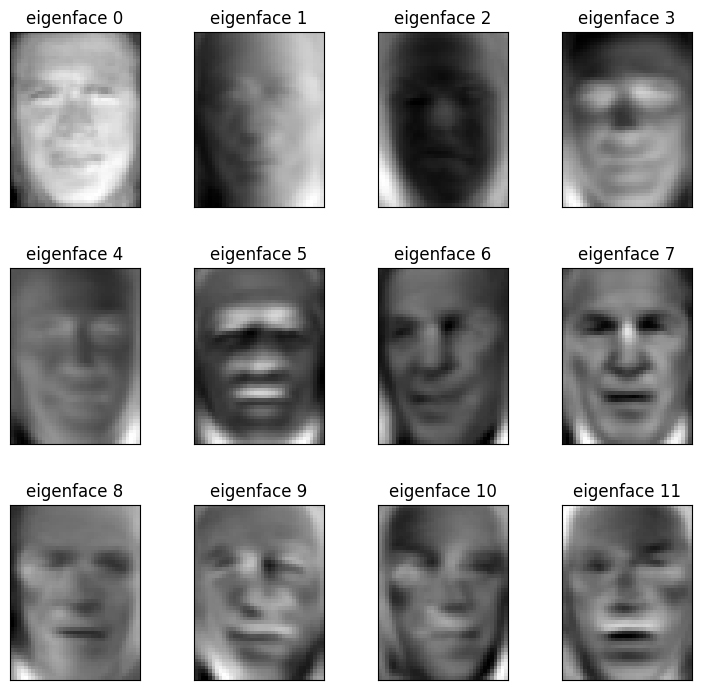

In [21]:
eigenface_titles = [f"eigenface {i}" for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)

plt.show()

The scatterplot below shows each face projected into the first two principal components (PC1 vs. PC2). Points are colored by person.

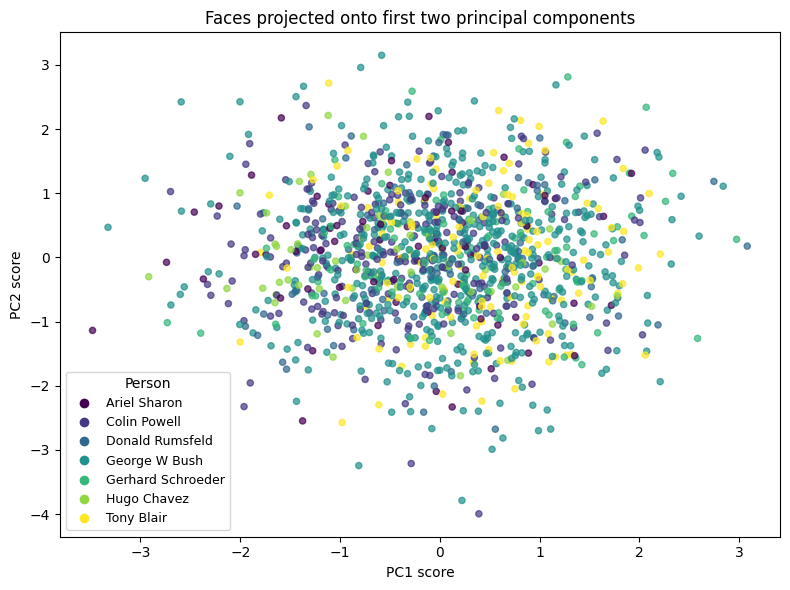

In [15]:
# --- PCA projection visualization (PC1 vs PC2) ---

# If there are many people, only label the first few to keep the legend readable
max_legend = 12
unique_classes = np.unique(y)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, alpha=0.7)

plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("Faces projected onto first two principal components")

# Build a compact legend (up to max_legend classes)
handles = []
labels = []
for cls in unique_classes[:max_legend]:
    handles.append(plt.Line2D([], [], marker='o', linestyle='', markersize=7,
                             markerfacecolor=sc.cmap(sc.norm(cls)), markeredgecolor='none'))
    labels.append(target_names[cls])
plt.legend(handles, labels, title="Person", loc="best", fontsize=9)

plt.tight_layout()
plt.show()


## Reconstruction from PCA (Inverse Transform)

Here we reconstruct faces back in the original pixel space using the learned PCA basis, then compare original vs. reconstructed images.

You can think of each reconstructured image, as the original image when only the most common aspects of being a human face is retained and the rest is treated as noise and dumped.

If the dataset is **dominated by one class**, you get better reconstructed results for that class.

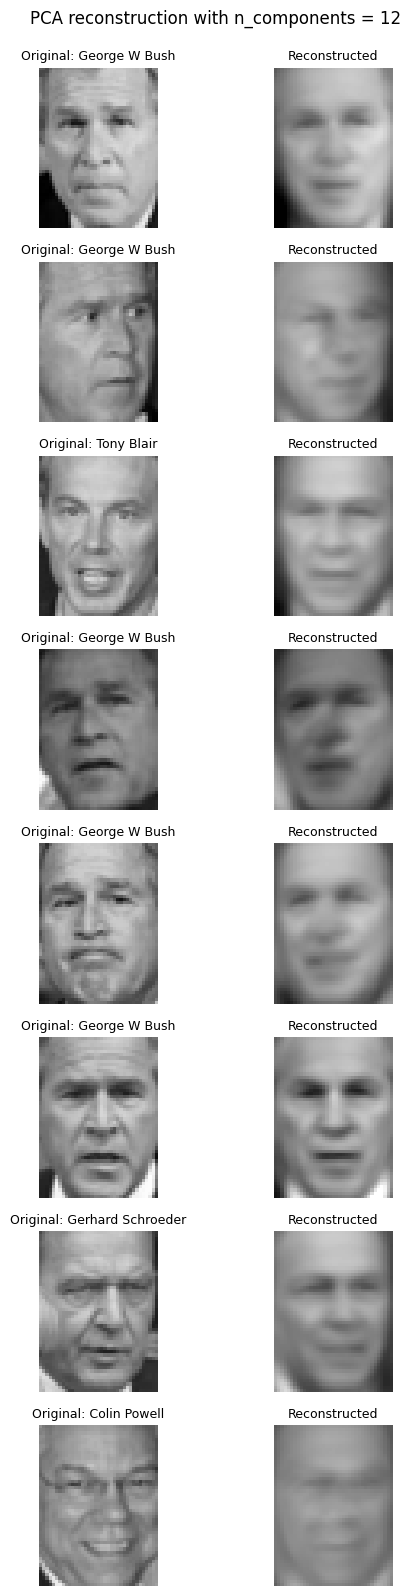

Average reconstruction MSE: 0.0075


In [22]:
# --- Reconstruction visualization ---
X_recon = pca.inverse_transform(X_pca)

# choose a consistent random subset of faces to display
rng = np.random.RandomState(42)
n_show = 8
idx = rng.choice(X.shape[0], size=n_show, replace=False)

# Choose display range for imshow
vmin, vmax = (0.0, 1.0) if X.max() <= 1.5 else (0.0, 255.0)

fig, axes = plt.subplots(nrows=n_show, ncols=2, figsize=(6, 2 * n_show))
for row, i in enumerate(idx):
    axes[row, 0].imshow(X[i].reshape(h, w), cmap=plt.cm.gray, vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"Original: {target_names[y[i]]}", fontsize=9)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(X_recon[i].reshape(h, w), cmap=plt.cm.gray, vmin=vmin, vmax=vmax)
    axes[row, 1].set_title("Reconstructed", fontsize=9)
    axes[row, 1].axis("off")

plt.suptitle(f"PCA reconstruction with n_components = {n_components}", y=0.995)
plt.tight_layout()
plt.show()

# Optional: summarize average reconstruction error (MSE) over the dataset
mse = np.mean((X - X_recon) ** 2)
print(f"Average reconstruction MSE: {mse:.4f}")
